| Data Path                               | Task         |
|-----------------------------------------|--------------|
| /src/data/Ratings.csv, /src/data/Users.csv | 2           |
| /src/data/Ratings.csv                   | 3, 4         |
| /src/data/Video_008.avi                 | 5            |
| /src/data/faces                         | bonus part   |

__Import libraries__

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
import umap as umap
from umap import UMAP
import time, cv2, os
from sklearn.utils import resample
from sklearn.metrics import silhouette_score
from glob import glob

/home/max/ML.Project_6.ID_1254805-1/daisymal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


__Task_1__ - Theory

Наиболее уязвимая модель KNN, т.к. при увеличении размерности расстояния между точками становятся мало значимыми. Также лог регрессия (без регуляризации) при увеличении кол-ва фичей может привести к переобучению и Наивный Байес, если у нас фичи не условно независимы.

PCA - это задача уменьшения размерности, SVD - это метод разложения матрицы. Т.е. это разные термины.

NMF и SVD - это оба метода разложения матрицы, но NMF - метод, в результате которого мы получаем 2 неотрицательные матрицы, произведение которых приблизительно равно исходной. SVD - метод, в результате которого получаются 3 матрицы: две ортогональные и 1 диагональная, математически точный метод, но менее интерпретируемый в отличии от NMF.

LLE - нелинейный тип задачи уменьшения размерности. Применяется тогда когда у нас данные лежат не в линейном многообразии. Основные этапы метода:
1) Найти соседей;
2) Вычислить веса восстановления;
3) Восстановить новую структуру в низкой размерности, сохранив веса.

__Task_2__ - Classification with sparse features

In [2]:
ratings = pd.read_csv("data/Ratings.csv")
print(ratings.shape)
ratings.head(2)

(1149780, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5


In [3]:
users = pd.read_csv("data/Users.csv")
print(users.shape)
users.head(2)

(278858, 3)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0


In [4]:
users.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

Filling gaps by median value

In [5]:
users['Age'] = users['Age'].fillna(users['Age'].median())

In [6]:
users.isna().sum()

User-ID     0
Location    0
Age         0
dtype: int64

In [7]:
user_ids = ratings['User-ID'].unique()
book_ids = ratings['ISBN'].unique()

print(f"User: {user_ids.shape}")
print(f"Book: {book_ids.shape}")

User: (105283,)
Book: (340556,)


In [8]:
user_id_to_index = {uid: i for i, uid in enumerate(user_ids)}
book_id_to_index = {isbn: i for i, isbn in enumerate(book_ids)}

rows = ratings['User-ID'].map(user_id_to_index)
cols = ratings['ISBN'].map(book_id_to_index)
data = ratings['Book-Rating']

interaction_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(book_ids)))

In [9]:
users_filtered = users[users['User-ID'].isin(user_ids)]
users_filtered = users_filtered.set_index('User-ID').loc[user_ids]

target = users_filtered['Age'].values

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(interaction_matrix, target, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"train: {X_train.shape}, {y_train.shape}")
print(f"val: {X_val.shape}, {y_val.shape}")
print(f"test: {X_test.shape}, {y_test.shape}")

train: (84226, 340556), (84226,)
val: (10528, 340556), (10528,)
test: (10529, 340556), (10529,)


Linear model and Random forest

In [11]:
def train_and_eval(model, X_train, y_train, X_val, y_val):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    score = model.score(X_val, y_val)
    return fit_time, score

In [12]:
ridge = Ridge()
param_ridge = {'alpha' : [0.01, 1, 100]}

ridge_grid = GridSearchCV(ridge, param_ridge, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 1, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,100


In [13]:
best_ridge = ridge_grid.best_estimator_

In [14]:
rf = RandomForestRegressor(max_depth=10, max_features='sqrt', random_state=42)
param_rf = {'n_estimators' : [50, 100]}

rf_grid = GridSearchCV(rf, param_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=2)
rf_grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'n_estimators': [50, 100]}"
,scoring,'neg_mean_squared_error'
,n_jobs,2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [15]:
best_rf = rf_grid.best_estimator_

In [16]:
ridge_time, ridge_score = train_and_eval(best_ridge, X_train, y_train, X_val, y_val)
rf_time, rf_score = train_and_eval(best_rf, X_train, y_train, X_val, y_val)

print(f"Baseline Ridge: time - {ridge_time:.3f} sec, score - ({ridge_score:.4f})")
print(f"Baseline RF: time - {rf_time:.3f} sec, score - ({rf_score:.4f})")

Baseline Ridge: time - 0.842 sec, score - (-0.1276)
Baseline RF: time - 13.075 sec, score - (0.0005)


PCA (Used alternative - TruncatedSVD)

In [17]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

svd = TruncatedSVD(n_components=10, random_state=42)
X_train_pca = svd.fit_transform(X_train_scaled)
X_val_pca = svd.transform(X_val_scaled)

In [18]:
ridge = Ridge()
param_ridge = {'alpha': [0.01, 1, 100]}

ridge_grid = GridSearchCV(ridge, param_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_pca, y_train)

best_ridge = ridge_grid.best_estimator_

In [19]:
rf = RandomForestRegressor(max_depth=10, max_features='sqrt', random_state=42)
param_rf = {'n_estimators': [50, 100]}

rf_grid = GridSearchCV(rf, param_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=2)
rf_grid.fit(X_train_pca, y_train)

best_rf = rf_grid.best_estimator_

In [20]:
ridge_time_pca, ridge_score_pca = train_and_eval(best_ridge, X_train_pca, y_train, X_val_pca, y_val)
rf_time_pca, rf_score_pca = train_and_eval(best_rf, X_train_pca, y_train, X_val_pca, y_val)

print(f"PCA Ridge: time - {ridge_time_pca:.3f} sec, score - ({ridge_score_pca:.4f})")
print(f"PCA RF: time - {rf_time_pca:.3f} sec, score - ({rf_score_pca:.4f})")

PCA Ridge: time - 0.008 sec, score - (-0.0002)
PCA RF: time - 15.344 sec, score - (0.0089)


UMAP

In [21]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_train_reduced = svd.fit_transform(X_train_scaled)
X_val_reduced = svd.transform(X_val_scaled)

X_train_reduced = X_train_reduced.astype(np.float32)
X_val_reduced = X_val_reduced.astype(np.float32)

umap_reducer = umap.UMAP(
    n_components=10,
    metric='cosine',
    densmap=False,
    n_neighbors=15,
    random_state=42
)
X_train_umap = umap_reducer.fit_transform(X_train_reduced)
X_val_umap = umap_reducer.transform(X_val_reduced)

In [22]:
ridge = Ridge()
param_ridge = {'alpha': [0.01, 1, 100]}

ridge_grid = GridSearchCV(ridge, param_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_umap, y_train)

best_ridge = ridge_grid.best_estimator_

In [23]:
rf = RandomForestRegressor(max_depth=10, max_features='sqrt', random_state=42)
param_rf = {'n_estimators': [50, 100]}

rf_grid = GridSearchCV(rf, param_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=2)
rf_grid.fit(X_train_umap, y_train)

best_rf = rf_grid.best_estimator_

In [24]:
ridge_time_umap, ridge_score_umap = train_and_eval(best_ridge, X_train_umap, y_train, X_val_umap, y_val)
rf_time_umap, rf_score_umap = train_and_eval(best_rf, X_train_umap, y_train, X_val_umap, y_val)

print(f"UMAP Ridge: time - {ridge_time_umap:.3f} sec, score - ({ridge_score_umap:.4f})")
print(f"UMAP RF:    time - {rf_time_umap:.3f} sec, score - ({rf_score_umap:.4f})")

UMAP Ridge: time - 0.008 sec, score - (0.0056)
UMAP RF:    time - 20.420 sec, score - (0.0142)


Comparing

In [25]:
results = [
    ["Baseline", "Ridge", ridge_time, rf_score],
    ["Baseline", "RandomForest", rf_time, rf_score],
    ["PCA (SVD→10)", "Ridge", ridge_time_pca, ridge_score_pca],
    ["PCA (SVD→10)", "RandomForest", rf_time_pca, rf_score_pca],
    ["UMAP (UMAP→10)", "Ridge", ridge_time_umap, ridge_score_umap],
    ["UMAP (UMAP→10)", "RandomForest", rf_time_umap, rf_score_umap],
]

df_results = pd.DataFrame(results, columns=["Method", "Model", "Time (sec)", "Score"])
print(df_results.to_string(index=False))

        Method        Model  Time (sec)     Score
      Baseline        Ridge    0.841587  0.000511
      Baseline RandomForest   13.075043  0.000511
  PCA (SVD→10)        Ridge    0.008193 -0.000209
  PCA (SVD→10) RandomForest   15.344421  0.008894
UMAP (UMAP→10)        Ridge    0.007828  0.005604
UMAP (UMAP→10) RandomForest   20.420065  0.014178


__Task_3__ - Visualization 

In [26]:
mnist_train = pd.read_csv("data/mnist_train.csv")
print(mnist_train.shape)
mnist_train.head(2)

(60000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
X = mnist_train.drop('label', axis=1)
y = mnist_train['label']

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"train: {X_train.shape}, {y_train.shape}")
print(f"train: {X_val.shape}, {y_val.shape}")

train: (48000, 784), (48000,)
train: (12000, 784), (12000,)


In [29]:
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_val = scaler.transform(X_val)

X_scaled_train = X_scaled_train.astype(np.float32)
X_scaled_val = X_scaled_val.astype(np.float32)

In [30]:
pca = PCA(n_components=2, random_state=42) # PCA
X_pca = pca.fit_transform(X_scaled_train)
print("PCA total explained variance:", pca.explained_variance_ratio_.sum())

PCA total explained variance: 0.09794631


In [31]:
svd = TruncatedSVD(n_components=2, random_state=42) # SVD
X_svd = svd.fit_transform(X_scaled_train)
print("SVD total explained variance:", svd.explained_variance_ratio_.sum())

SVD total explained variance: 0.09794602


In [32]:
pca_rand = PCA(n_components=2, svd_solver='randomized', random_state=42) # Rand_PCA
X_randsvd = pca_rand.fit_transform(X_scaled_train)
print("Randomized PCA total explained variance:", pca_rand.explained_variance_ratio_.sum())

Randomized PCA total explained variance: 0.09794639


In [33]:
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced_train = svd.fit_transform(X_scaled_train)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca') # t-SNE
X_tsne = tsne.fit_transform(X_reduced_train)

total_variance_2comp = svd.explained_variance_ratio_.sum()
print(f"Total explained variance: {total_variance_2comp}")

Total explained variance: 0.5553945899009705


In [34]:
umap_reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42) # UMAP
X_umap = umap_reducer.fit_transform(X_reduced_train)

In [35]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=5, method='standard') # LLE
X_lle_sample = resample(X_reduced_train, n_samples=30000, random_state=42)
X_lle = lle.fit_transform(X_lle_sample)

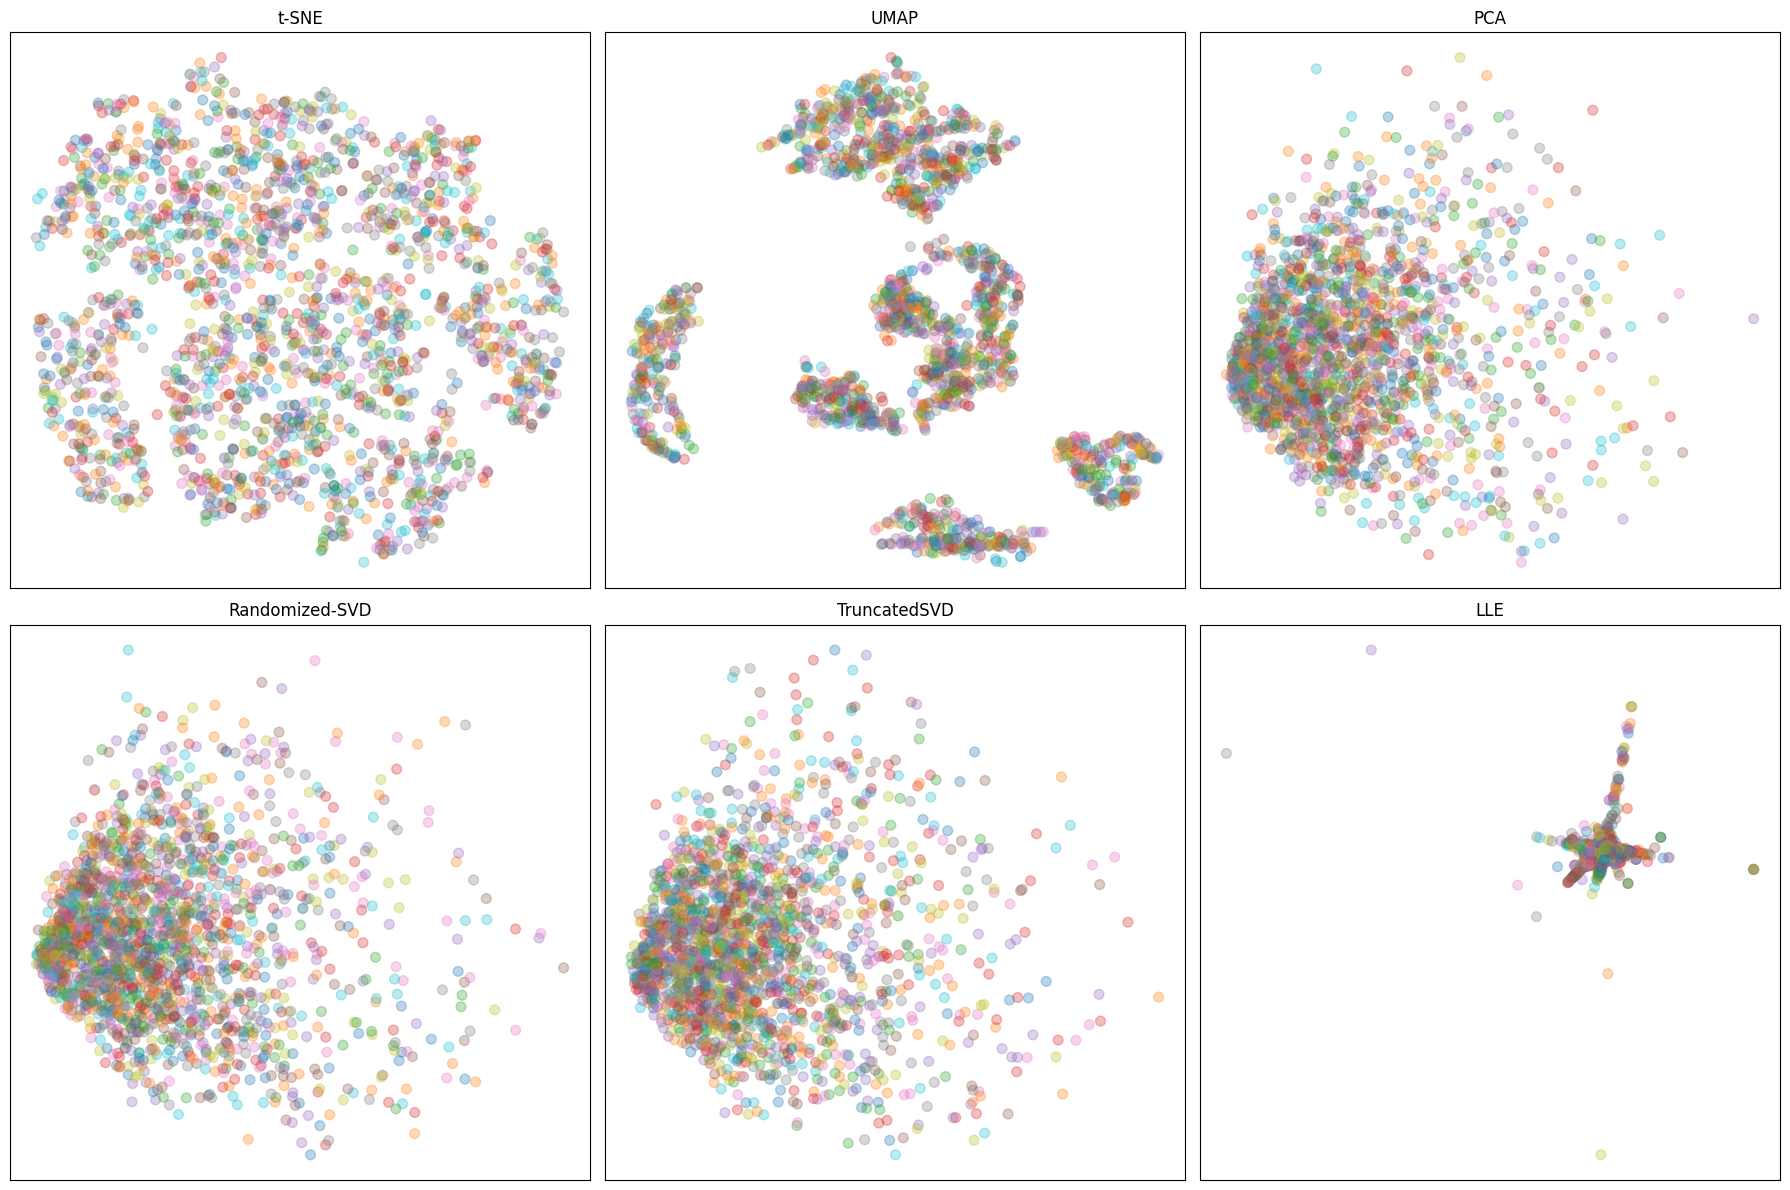

In [36]:
np.random.seed(42)

datasets = [
    ("t-SNE", X_tsne, y[:len(X_tsne)]),
    ("UMAP", X_umap, y[:len(X_umap)]),
    ("PCA", X_pca, y[:len(X_pca)]),
    ("Randomized-SVD", X_randsvd, y[:len(X_randsvd)]),
    ("TruncatedSVD", X_svd, y[:len(X_svd)]),
    ("LLE", X_lle, y[:len(X_lle)])
]

plt.figure(figsize=(18, 12))

for i, (name, X_proj, y_proj) in enumerate(datasets, 1):
    n_samples = len(X_proj)
    idx = np.random.choice(n_samples, size=min(2000, n_samples), replace=False)

    plt.subplot(2, 3, i)
    plt.scatter(X_proj[idx, 0], X_proj[idx, 1], c=y_proj[idx], cmap='tab10', s=50, alpha=0.3)
    plt.title(name)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [37]:
min_len = min(len(X_pca), len(X_svd), len(X_randsvd), len(X_tsne), len(X_umap), len(X_lle))

X_pca_sub     = X_pca[:min_len]
X_svd_sub     = X_svd[:min_len]
X_randsvd_sub = X_randsvd[:min_len]
X_tsne_sub    = X_tsne[:min_len]
X_umap_sub    = X_umap[:min_len]
X_lle_sub     = X_lle[:min_len]

y_sub = y[:min_len]

scores = {
    "PCA": silhouette_score(X_pca_sub, y_sub),
    "TruncatedSVD": silhouette_score(X_svd_sub, y_sub),
    "Randomized-SVD": silhouette_score(X_randsvd_sub, y_sub),
    "t-SNE": silhouette_score(X_tsne_sub, y_sub),
    "UMAP": silhouette_score(X_umap_sub, y_sub),
    "LLE": silhouette_score(X_lle_sub, y_sub)
}

df_scores = pd.DataFrame(list(scores.items()), columns=["Method", "Silhouette Score"])
df_scores = df_scores.sort_values(by="Silhouette Score", ascending=False).reset_index(drop=True)

print(df_scores.set_index(df_scores['Method']).drop(columns = 'Method'))

                Silhouette Score
Method                          
t-SNE                  -0.012647
UMAP                   -0.015317
PCA                    -0.015910
Randomized-SVD         -0.015911
TruncatedSVD           -0.015912
LLE                    -0.035935


__Task_4__ - SVD

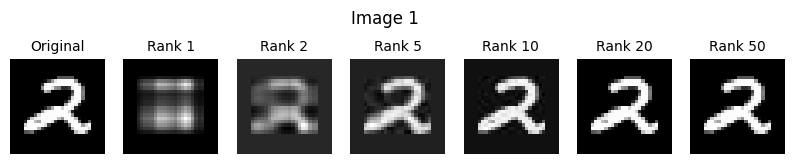

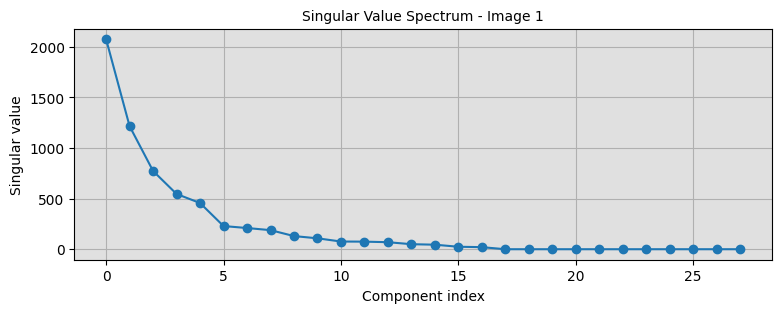

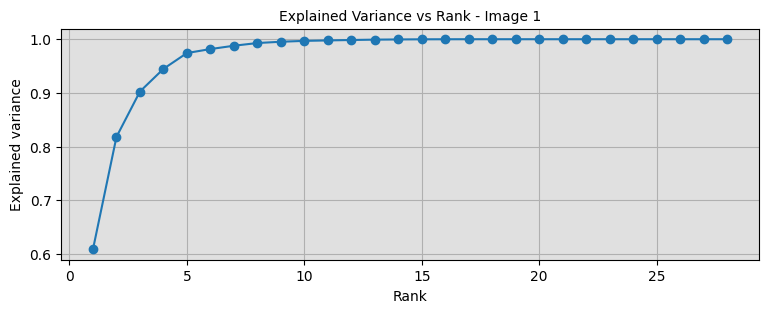

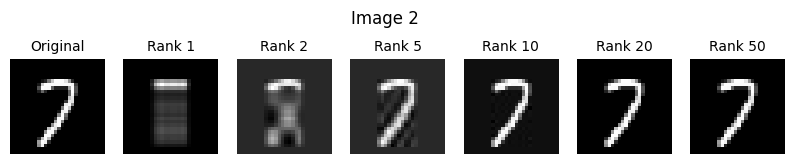

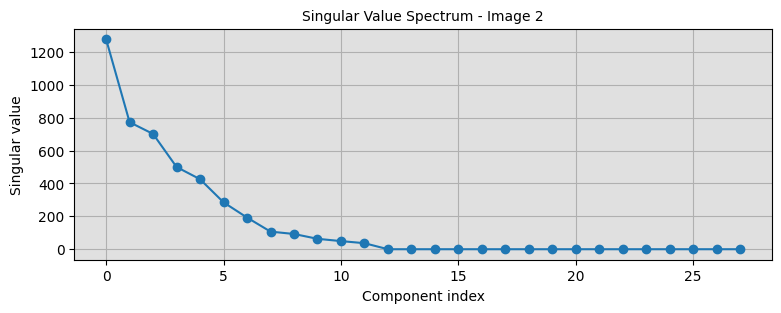

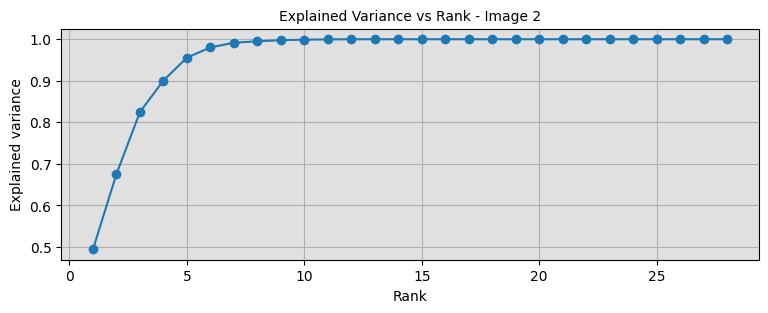

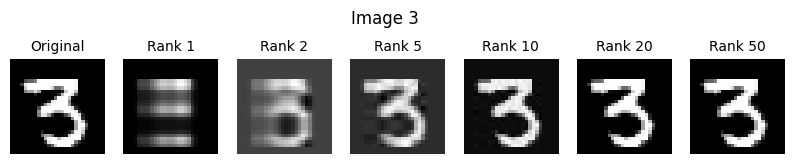

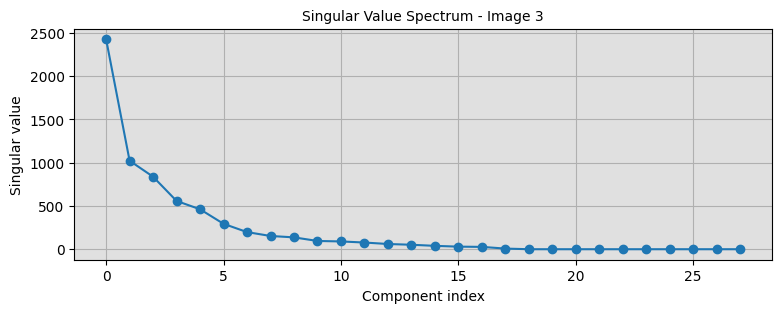

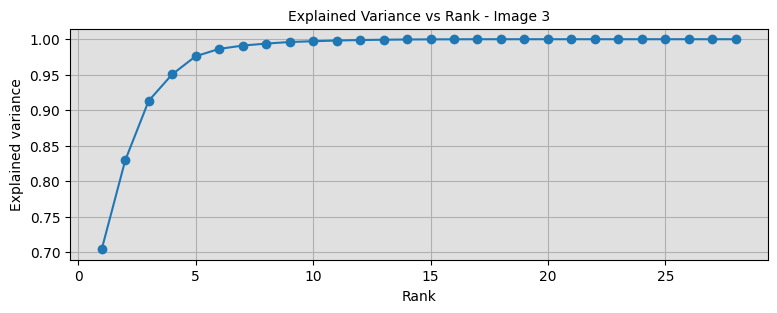

In [38]:
X_train_np = X_train.to_numpy()

np.random.seed(42)
idx = np.random.choice(len(X_train_np), size=3, replace=False)
images = X_train_np[idx].reshape(-1, 28, 28)

ranks = [1, 2, 5, 10, 20, 50]

for img_i, img in enumerate(images):
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    
    plt.figure(figsize=(10, 2))
    plt.subplot(1, len(ranks)+1, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original", fontsize=10)
    plt.axis('off')

    for j, r in enumerate(ranks, start=2):
        Ur = U[:, :r]
        Sr = np.diag(S[:r])
        Vr = Vt[:r, :]
        img_approx = Ur @ Sr @ Vr
        plt.subplot(1, len(ranks)+1, j)
        plt.imshow(img_approx, cmap='gray')
        plt.title(f"Rank {r}", fontsize=10)
        ax = plt.gca()
        ax.set_facecolor('#e0e0e0')
        plt.axis('off')

    plt.suptitle(f"Image {img_i+1}")
    plt.show()

    plt.figure(figsize=(9, 3))
    plt.plot(S, 'o-')
    plt.title(f"Singular Value Spectrum - Image {img_i+1}", fontsize=10)
    plt.xlabel("Component index")
    plt.ylabel("Singular value")
    plt.grid(True)
    ax = plt.gca()
    ax.set_facecolor('#e0e0e0')
    plt.show()

    explained_variance = np.cumsum(S**2) / np.sum(S**2)
    plt.figure(figsize=(9, 3))
    plt.plot(np.arange(1, len(S)+1), explained_variance, 'o-')
    plt.title(f"Explained Variance vs Rank - Image {img_i+1}", fontsize=10)
    plt.xlabel("Rank")
    plt.ylabel("Explained variance")
    plt.grid(True)
    ax = plt.gca()
    ax.set_facecolor('#e0e0e0')
    plt.show()

__Task_5__

In [39]:
img = cv2.VideoCapture('data/Video_008.avi')

frames, num_frames, count = [], 50, 0

while count < num_frames:
    _, frame = img.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray.flatten())
    count += 1

img.release()

A = np.array(frames).T

In [40]:
U, S, VT = np.linalg.svd(A, full_matrices=False)

rank = 1
A_bg = U[:, :rank] @ np.diag(S[:rank]) @ VT[:rank, :]
background = A_bg[:, 0].reshape(gray.shape)
first_frame = frames[0].reshape(gray.shape)

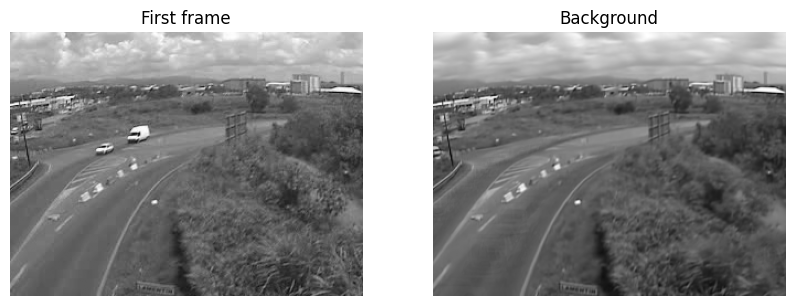

In [41]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(first_frame, cmap='gray')
plt.title("First frame")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(background, cmap='gray')
plt.title("Background")
plt.axis('off')
plt.show()

__Bonus_task__

In [42]:
# base_dir = 'data/faces/train'

# for subtype in os.listdir(base_dir):
#     subtype_path = os.path.join(base_dir, subtype)
#     if not os.path.isdir(subtype_path): continue
#     files = [f for f in os.listdir(subtype_path) 
#              if os.path.isfile(os.path.join(subtype_path, f))]
#     print(f"{subtype}: {len(files)} files")

In [43]:
# base_dir = 'data/faces/validation'

# for subtype in os.listdir(base_dir):
#     subtype_path = os.path.join(base_dir, subtype)
#     if not os.path.isdir(subtype_path): continue
#     files = [f for f in os.listdir(subtype_path) 
#              if os.path.isfile(os.path.join(subtype_path, f))]
#     print(f"{subtype}: {len(files)} files")

In [44]:
# def trim_files_in_dir(base_dir, target_count):
#     for subtype in os.listdir(base_dir):
#         subtype_path = os.path.join(base_dir, subtype)
#         if not os.path.isdir(subtype_path): continue
#         files = [f for f in os.listdir(subtype_path) if os.path.isfile(os.path.join(subtype_path, f))]
#         files.sort()
#         if len(files) > target_count:
#             extra_files = files[target_count:]
#             for f in extra_files:
#                 os.remove(os.path.join(subtype_path, f))

# trim_files_in_dir('data/faces/train', 436)
# trim_files_in_dir('data/faces/validation', 111)

In [45]:
# base_dir = 'data/faces/train'

# for subtype in os.listdir(base_dir):
#     subtype_path = os.path.join(base_dir, subtype)
#     if not os.path.isdir(subtype_path): continue
#     files = [f for f in os.listdir(subtype_path) 
#              if os.path.isfile(os.path.join(subtype_path, f))]
#     print(f"{subtype}: {len(files)} files")

In [46]:
# base_dir = 'data/faces/validation'

# for subtype in os.listdir(base_dir):
#     subtype_path = os.path.join(base_dir, subtype)
#     if not os.path.isdir(subtype_path): continue
#     files = [f for f in os.listdir(subtype_path) 
#              if os.path.isfile(os.path.join(subtype_path, f))]
#     print(f"{subtype}: {len(files)} files")

In [47]:
img_size = (64, 64)
train_dir = 'data/faces/train'

X = []
y = []

for label in os.listdir(train_dir):
    folder = os.path.join(train_dir, label)
    for img_path in glob(folder + '/*.jpg'):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, img_size)
        X.append(img.flatten())
        y.append(label)

X = np.array(X)
y = np.array(y)

In [48]:
pca = PCA(n_components=200)
X_pca = pca.fit_transform(X)

In [49]:
mean_happy = X_pca[y == 'happy'].mean(axis=0)
mean_sad = X_pca[y == 'disgust'].mean(axis=0)
direction = mean_happy - mean_sad

In [50]:
sad_idx = np.where(y == 'disgust')[0][0]
sad_face_pca = X_pca[sad_idx]
happy_version_pca = sad_face_pca + direction
happy_version = pca.inverse_transform(happy_version_pca)
happy_version_img = happy_version.reshape(img_size)
sad_face_img = X[sad_idx].reshape(img_size)

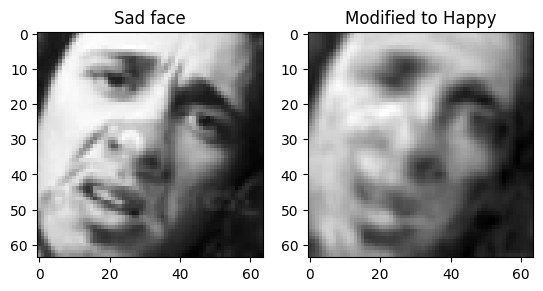

In [51]:
plt.subplot(1, 2, 1)
plt.imshow(sad_face_img, cmap='gray')
plt.title("Sad face")

plt.subplot(1, 2, 2)
plt.imshow(happy_version_img, cmap='gray')
plt.title("Modified to Happy")
plt.show()